In [ ]:
import os
import numpy as np
import scipp as sc
import MDAnalysis as mda
from MDAnalysis.coordinates.memory import MemoryReader
from kinisi.analyze import DiffusionAnalyzer
from scipy.linalg import pinvh
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
base = Path.home()

(base / "data").mkdir(parents=True, exist_ok=True)

(base / "plots").mkdir(parents=True, exist_ok=True)

In [3]:
def walk(atoms, timesteps, jump_size, seed):
    possible_moves = np.zeros((6, 3))
    j = 0

    for i in range(0, 6, 2):
        possible_moves[i, j] = jump_size
        possible_moves[i + 1, j] = -jump_size
        j += 1

    choices = seed.choice(6, size=(atoms, timesteps))

    steps = possible_moves[choices]
    
    return np.cumsum(steps, axis=1)

In [4]:
def build_analyzer(seed, atoms=128, length=128):
    rng = np.random.RandomState(seed)

    steps = walk(atoms, length, np.sqrt(6), rng)

    dims = np.tile([200.0, 200.0, 200.0, 90.0, 90.0, 90.0], (steps.shape[1], 1))

    u = mda.Universe.empty(steps.shape[0], trajectory=True)

    u.add_TopologyAttr('name', [f'Atom{k}' for k in range(steps.shape[0])])

    u.add_TopologyAttr('type', ['A'] * steps.shape[0])

    u.trajectory = MemoryReader(np.transpose(steps, (1, 0, 2)), dimensions=dims, delta=1.0)

    a = DiffusionAnalyzer.from_universe(u, time_step=1.0 * sc.Unit('s'), step_skip=1,
                                        distance_unit=sc.Unit('m'), specie='A',
                                        dt=sc.linspace(dim='time interval', start=2 * sc.Unit('s'),
                                        stop=length * sc.Unit('s'), num=126), progress=False)
    
    a.diffusion(2 * sc.Unit('s'), progress=False)
    
    return a

In [5]:
for s in range(8):
    a = build_analyzer(s)

    D = np.median(a.D.values)

    cond = np.linalg.cond(a.diff.covariance_matrix.values)
    
    print(f"seed {s}: D = {D:.4e}, cond = {cond:.3e}")

/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/kappa-kinisi/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2350: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)


seed 0: D = 1.0060e+04, cond = 1.023e+16
seed 1: D = 9.9702e+03, cond = 2.975e+16
seed 2: D = 1.0116e+04, cond = 9.760e+15
seed 3: D = 9.9231e+03, cond = 1.444e+16
seed 4: D = 9.8305e+03, cond = 3.342e+07
seed 5: D = 1.0047e+04, cond = 1.131e+16
seed 6: D = 1.0264e+04, cond = 2.016e+16
seed 7: D = 1.0184e+04, cond = 1.060e+16


In [6]:
ckpt = base / "data" / "rw_32atoms_16k.npy"

n_seeds = 16000

ATOMS = 32

D_normal = 9980.0  

def is_anomalous(D, Dn):

    if not np.isfinite(D):
        return True
    
    if D <= 0:
        return True
    
    r = D / Dn

    return (r < 0.5) or (r > 2.0)

if os.path.exists(ckpt):
    records = list(np.load(ckpt, allow_pickle=True))

    done = {r["seed"] for r in records}

    print(f"resuming from {len(done)} done")

else:
    records, done = [], set()

if not done:
    _a = build_analyzer(0, atoms=ATOMS)

    print(f"pre flight OK: seed 0 D={np.median(_a.D.values):.1f}")




fail_streak = 0

for s in tqdm(range(n_seeds)):

    if s in done:

        continue

    try:
        a = build_analyzer(s, atoms=ATOMS)

        cov = a.diff.covariance_matrix.values
        ev = np.linalg.eigvalsh(cov)

        rec = {"seed": s, "D": float(np.median(a.D.values)),
               "D_std": float(np.std(a.D.values)),
               "cond": float(np.linalg.cond(cov)),
               "lmin": float(ev[0]), "lmax": float(ev[-1]),
               "frac_neg": float(np.mean(ev < 0))}
        
        fail_streak = 0




    except Exception as e:
        rec = {"seed": s, "D": np.nan, "cond": np.nan, "lmin": np.nan,
               "lmax": np.nan, "frac_neg": np.nan, "error": f"{type(e).__name__}: {e}"}
        
        fail_streak += 1

        if fail_streak >= 20:
            np.save(ckpt, np.array(records + [rec], dtype=object))
            raise RuntimeError("aborting - fix the error")
        
    records.append(rec)

    if len(records) % 250 == 0:
        np.save(ckpt, np.array(records, dtype=object))


np.save(ckpt, np.array(records, dtype=object))

print(f"done: {len(records)} seeds")

resuming from 16000 done


100%|██████████| 16000/16000 [00:00<00:00, 9232200.30it/s]

done: 16000 seeds


In [7]:
records = list(np.load(ckpt, allow_pickle=True))

D = np.array([r["D"] for r in records])

cond = np.array([r["cond"] for r in records])

seeds = np.array([r["seed"] for r in records])

finite = np.isfinite(D)

Dn = np.nanmedian(D[finite & (D > 0)])

anom = (~finite) | (D <= 0) | (D < 0.5*Dn) | (D > 2*Dn)


print(f"total: {len(records)},  normal D scale: {Dn:.2e}")

print(f"anomalous: {np.sum(anom)} ({100*np.mean(anom):.3f}%)")

print(f"  D <= 0:            {np.sum(finite & (D<=0))}")

print(f"  near-zero (<0.1N): {np.sum(finite & (D>0) & (D<0.1*Dn))}")

print(f"  high (>2N):        {np.sum(finite & (D>2*Dn))}")



print(f"\nconditioning link:")

print(f"  median cond normal:    {np.nanmedian(cond[~anom & finite]):.2e}")

print(f"  median cond anomalous: {np.nanmedian(cond[anom & finite]):.2e}")

bad = seeds[anom]

print(f"\nbad seeds: {list(bad)}")

total: 16000,  normal D scale: 9.98e+03
anomalous: 3 (0.019%)
  D <= 0:            0
  near-zero (<0.1N): 2
  high (>2N):        0

conditioning link:
  median cond normal:    1.59e+16
  median cond anomalous: 2.06e+16

bad seeds: [np.int64(295), np.int64(14460), np.int64(15770)]


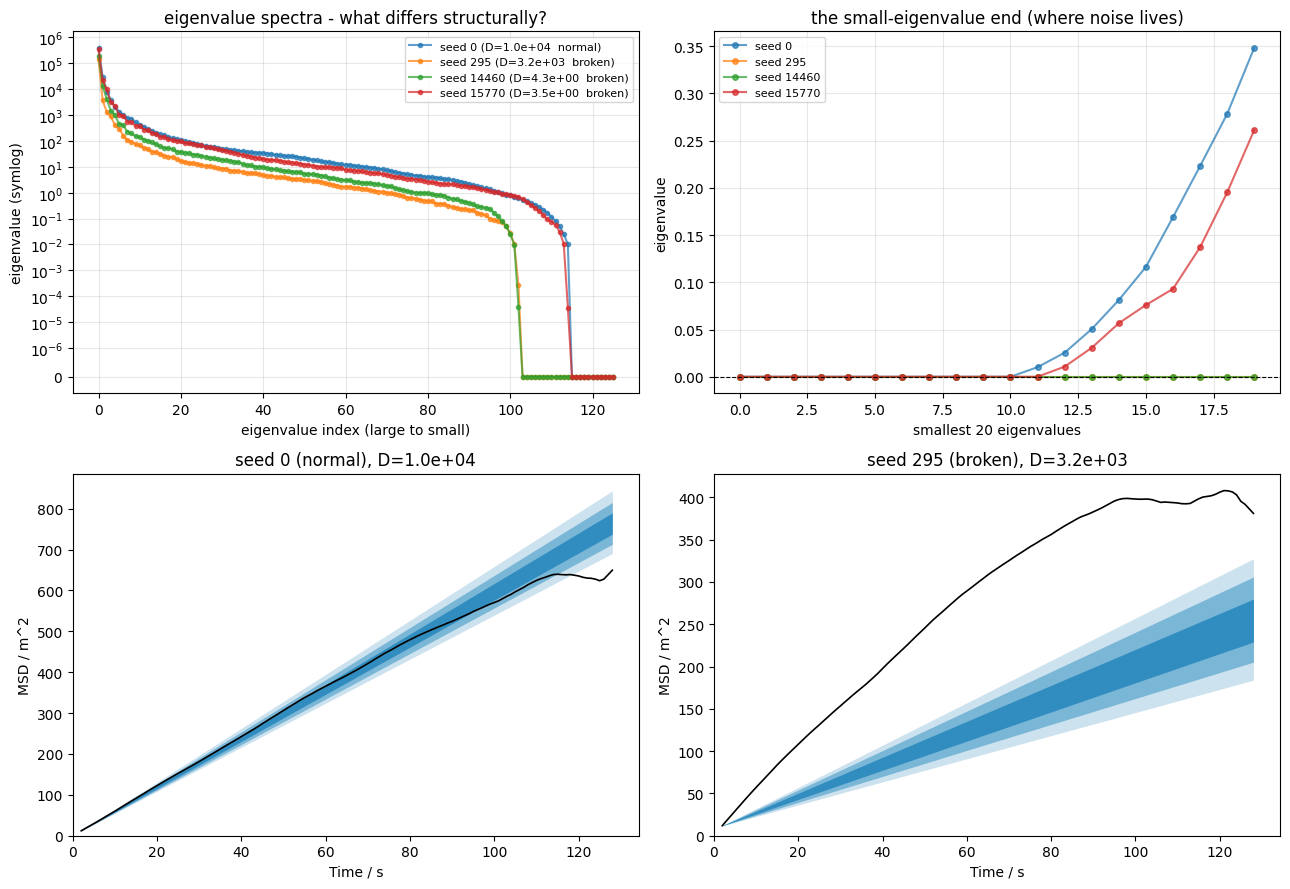

In [8]:
bad = [295, 14460, 15770]

normal = 0

fig, axes = plt.subplots(2, 2, figsize=(13, 9))



ax = axes[0, 0]

for s in [normal] + bad:
    a = build_analyzer(s, atoms=32)

    ev = np.linalg.eigvalsh(a.diff.covariance_matrix.values)

    D = np.median(a.D.values)

    lbl = f"seed {s} (D={D:.1e}{'  normal' if s==normal else '  broken'})"

    ax.plot(np.sort(ev)[::-1], 'o-', ms=3, alpha=0.7, label=lbl)

ax.set_yscale("symlog", linthresh=1e-6)

ax.set_xlabel("eigenvalue index (large to small)")

ax.set_ylabel("eigenvalue (symlog)")

ax.set_title("eigenvalue spectra - what differs structurally?")

ax.legend(fontsize=8)

ax.grid(alpha=0.3)






ax = axes[0, 1]

for s in [normal] + bad:
    a = build_analyzer(s, atoms=32)

    ev = np.sort(np.linalg.eigvalsh(a.diff.covariance_matrix.values))

    ax.plot(ev[:20], 'o-', ms=4, alpha=0.7, label=f"seed {s}")

ax.axhline(0, color='k', lw=0.8, ls='--')

ax.set_xlabel("smallest 20 eigenvalues")

ax.set_ylabel("eigenvalue")

ax.set_title("the small-eigenvalue end (where noise lives)")

ax.legend(fontsize=8)

ax.grid(alpha=0.3)






credible_intervals = [[16, 84], [2.5, 97.5], [0.15, 99.85]]

alpha_v = [0.6, 0.4, 0.2]

for ax, s, tag in [(axes[1,0], normal, "normal"), (axes[1,1], bad[0], "broken")]:
    a = build_analyzer(s, atoms=32)

    ax.plot(a.dt.values, a.msd.values, 'k-', lw=1.2)

    for i, ci in enumerate(credible_intervals):
        lo, hi = np.percentile(a.distributions, ci, axis=1)

        ax.fill_between(a.dt.values, lo, hi, alpha=alpha_v[i], color='#0173B2', lw=0)

    ax.set_xlabel(f"Time / {a.dt.unit}")

    ax.set_ylabel(f"MSD / {a.msd.unit}")

    ax.set_xlim(0, None); ax.set_ylim(0, None)

    ax.set_title(f"seed {s} ({tag}), D={np.median(a.D.values):.1e}")

plt.tight_layout()

plt.show()

In [9]:
from scipy.stats import linregress

for s in [0, 295, 14460, 15770]:

    a = build_analyzer(s, atoms=32)

    dt = a.dt.values

    msd = a.msd.values

    lr = linregress(dt, msd)

    p1 = np.polyfit(dt, msd, 1)

    p2 = np.polyfit(dt, msd, 2)

    resid1 = np.sum((msd - np.polyval(p1, dt))**2)

    resid2 = np.sum((msd - np.polyval(p2, dt))**2)

    curve_improvement = 1 - resid2/resid1
    
    print(f"seed {s}: simple-slope D = {lr.slope/(2*3):.1e}, "
          f"r^2 = {lr.rvalue**2:.4f}, "
          f"quad term = {p2[0]:+.3f}, "
          f"curvature reduces resid by {curve_improvement:.1%}")

seed 0: simple-slope D = 9.0e-01, r^2 = 0.9888, quad term = -0.015, curvature reduces resid by 76.4%
seed 295: simple-slope D = 5.4e-01, r^2 = 0.9324, quad term = -0.026, curvature reduces resid by 93.5%
seed 14460: simple-slope D = 7.4e-01, r^2 = 0.9912, quad term = -0.012, curvature reduces resid by 92.0%
seed 15770: simple-slope D = 1.1e+00, r^2 = 0.9988, quad term = -0.004, curvature reduces resid by 34.6%


In [10]:
def build_raw_cov(a):

    da = a.diff.dg['da']

    variances = da.data.variances

    n_samples = da.coords['n_samples'].values

    n = variances.size

    cov = np.zeros((n, n))

    for i in range(n):

        for j in range(i, n):

            ratio = n_samples[i] / n_samples[j]

            cov[i, j] = ratio * variances[i]

            cov[j, i] = cov[i, j]

    regime = a.diff.diff_regime

    return cov[regime:, regime:]






def gls_D_self(cov, t, y, dim=3, inverse="pinvh"):

    A = np.column_stack([t, np.ones_like(t)])

    inv = pinvh(cov) if inverse == "pinvh" else np.linalg.inv(cov)

    beta = np.linalg.solve(A.T @ inv @ A, A.T @ inv @ y)

    return beta[0] / (2 * dim)




def adaptive_floor(m, c=0.25):

    v, V = np.linalg.eigh(m)

    if v[0] < 0:

        fl = c * (-v[0]); v = np.where(v < fl, fl, v)

    return (V * v) @ V.T






def mineig_floor(m, kappa=1e3):

    v, V = np.linalg.eigh(m)

    fl = v[-1] / kappa

    return (V * np.where(v < fl, fl, v)) @ V.T





for seed in [15770, 14460, 295, 0]:

    a = build_analyzer(seed, atoms=32)

    raw = build_raw_cov(a)

    ev = np.linalg.eigvalsh(raw)

    regime = a.diff.diff_regime

    t = a.diff.dg['da'].coords['time interval'][regime:].values

    y = a.diff.dg['da']['time interval', regime:].values

    D_raw = gls_D_self(raw, t, y, inverse="pinvh")

    tag = "normal" if seed == 0 else "broken"

    print(f"seed {seed} ({tag}):")

    print(f"  raw smallest eig: {np.round(ev[:4], 5)}  (frac_neg {np.mean(ev<0):.1%})")

    print(f"  self built GLS D (pinvh): {D_raw:.2f}")

seed 15770 (broken):
  raw smallest eig: [-1122.21108 -1009.17788  -241.70749   -81.01797]  (frac_neg 8.7%)
  self built GLS D (pinvh): -1.93
seed 14460 (broken):
  raw smallest eig: [-1903.80959  -803.41281  -390.27473  -193.33063]  (frac_neg 18.3%)
  self built GLS D (pinvh): -0.90
seed 295 (broken):
  raw smallest eig: [-1496.04249  -945.16825  -248.81847  -121.17913]  (frac_neg 18.3%)
  self built GLS D (pinvh): 0.33
seed 0 (normal):
  raw smallest eig: [-6802.34472  -942.21432  -463.59094  -178.54401]  (frac_neg 8.7%)
  self built GLS D (pinvh): 1.00


In [ ]:
bad = [tuple(map(int, b)) for b in np.load(base / "data" / "all_bad_seeds.npy")]


ckpt_fix = base / "data" / "anomaly_realfit_all14.npy"


if os.path.exists(ckpt_fix):
    rows = list(np.load(ckpt_fix, allow_pickle=True))
    done = {(r["atoms"], r["seed"], r["method"]) for r in rows}
    print(f"resuming - {len(rows)} fits already done")

else:
    rows, done = [], set()

methods = [("raw", lambda m: m), ("adaptive", adaptive_floor), ("mineig1e3", mineig_floor)]



for atoms, seed in tqdm(bad):
    todo = [(n, f) for n, f in methods if (atoms, seed, n) not in done]

    if not todo:
        continue

    a = build_analyzer(seed, atoms=atoms)
    d_ols = float(linregress(a.dt.values, a.msd.values).slope / (2 * 3))

    for name, fn in todo:
        try:
            post = realfit_with_treatment(seed, fn, atoms=atoms)
            rows.append({"atoms": atoms, "seed": seed, "method": name, "d_ols": d_ols,
                         "d": float(np.median(post)), "d_std": float(np.std(post))})
            
        except Exception as e:
            rows.append({"atoms": atoms, "seed": seed, "method": name, "d_ols": d_ols,
                         "d": np.nan, "d_std": np.nan, "error": f"{type(e).__name__}: {e}"})
            
        np.save(ckpt_fix, np.array(rows, dtype=object))



print(f"\n{'atoms':>5} {'seed':>6} {'d_ols':>7} {'raw':>8} {'adaptive':>9} {'mineig1e3':>10}")



for atoms, seed in bad:
    g = {r["method"]: r for r in rows if r["atoms"] == atoms and r["seed"] == seed}

    if not g:
        continue

    vals = [g.get(m, {}).get("d", np.nan) for m in ("raw", "adaptive", "mineig1e3")]

    cells = " ".join(f"{v:9.3f}" if np.isfinite(v) else f"{'nan':>9}" for v in vals)
    
    print(f"{atoms:5d} {seed:6d} {g['raw']['d_ols']:7.3f} {cells}")

100%|██████████| 1/1 [00:00<00:00,  2.76it/s]


atoms   seed   d_ols      raw  adaptive  mineig1e3
   16      3   1.106       nan       nan       nan


In [12]:
def realfit_with_treatment(seed, treatment_fn, atoms=32, start=2.0):

    a = build_analyzer(seed, atoms=atoms)

    raw = build_raw_cov(a)

    treated = treatment_fn(raw)

    template = a.diff.compute_covariance_matrix()

    treated_var = sc.array(dims=template.dims, values=treated, unit=template.unit)

    original = a.diff.compute_covariance_matrix

    a.diff.compute_covariance_matrix = lambda: treated_var



    try:
        a.diff.bayesian_regression(start * sc.Unit('s'), progress=False)
        D_post = a.diff.gradient.values / (2 * 3)
    finally:
        a.diff.compute_covariance_matrix = original
    return D_post




seed = 15770

post_raw = realfit_with_treatment(seed, lambda m: m)

post_ada = realfit_with_treatment(seed, adaptive_floor)

print(f"seed {seed} (broken, target D=1.0):")

print(f"  raw (no recond):  D median = {np.median(post_raw):.3f}")

print(f"  adaptive floor:   D median = {np.median(post_ada):.3f}")

seed 15770 (broken, target D=1.0):
  raw (no recond):  D median = 0.000
  adaptive floor:   D median = 1.050


In [13]:
treatments = {"raw (no recond)": lambda m: m,
              "adaptive floor":  adaptive_floor,
              "mineig 1e3":      lambda m: mineig_floor(m, 1e3)}


print(f"{'seed':>7s} " + " ".join(f"{n:>16s}" for n in treatments) + "   target")

for seed in [0, 15770, 14460, 295]:
    row = []

    for name, fn in treatments.items():

        try:
            post = realfit_with_treatment(seed, fn)
            row.append(f"{np.median(post):16.3f}")

        except Exception:
            row.append(f"{'FAIL':>16s}")
    tag = "1.0 (normal)" if seed == 0 else "1.0 (broken)"
    
    print(f"{seed:7d} " + " ".join(row) + f"   {tag}")

   seed  raw (no recond)   adaptive floor       mineig 1e3   target
      0            0.996            0.978            0.947   1.0 (normal)
  15770            0.000            1.046            1.059   1.0 (broken)
  14460            0.000            0.839            0.836   1.0 (broken)
    295            0.329            0.574            0.486   1.0 (broken)


In [14]:
def model_variance_S15(a, kappa=np.sqrt(6), dim=3):

    da = a.diff.dg['da']

    n_samples = da.coords['n_samples'].values

    n_steps = da.coords['time interval'].values

    regime = a.diff.diff_regime

    n = n_steps[regime:]

    Nprime = n_samples[regime:]

    return (2 * n**2 * kappa**4) / (dim * Nprime)




def cov_from_variance_S30(a, sigma2):

    da = a.diff.dg['da']

    n_samples = da.coords['n_samples'].values

    regime = a.diff.diff_regime

    Nprime = n_samples[regime:]

    k = sigma2.size

    cov = np.zeros((k, k))

    for i in range(k):

        for j in range(i, k):

            cov[i, j] = sigma2[i] * Nprime[i] / Nprime[j]

            cov[j, i] = cov[i, j]
            
    return cov

In [15]:
a0 = build_analyzer(0, atoms=32)

sigma2_true = model_variance_S15(a0)

cov_true = cov_from_variance_S30(a0, sigma2_true)

ev_true = np.linalg.eigvalsh(cov_true)



print(f"  smallest 5: {np.round(ev_true[:5], 4)}")

print(f"  largest:    {ev_true[-1]:.2f}")

print(f"  frac_neg:   {np.mean(ev_true < 0):.1%}  (should be 0 - it is de-noised)")

print(f"  condition:  {ev_true[-1]/ev_true[0]:.2e}" if ev_true[0] > 0 else "  singular")

  smallest 5: [0.012  0.0294 0.0539 0.0856 0.1245]
  largest:    345667.84
  frac_neg:   0.0%  (should be 0 - it is de-noised)
  condition:  2.88e+07


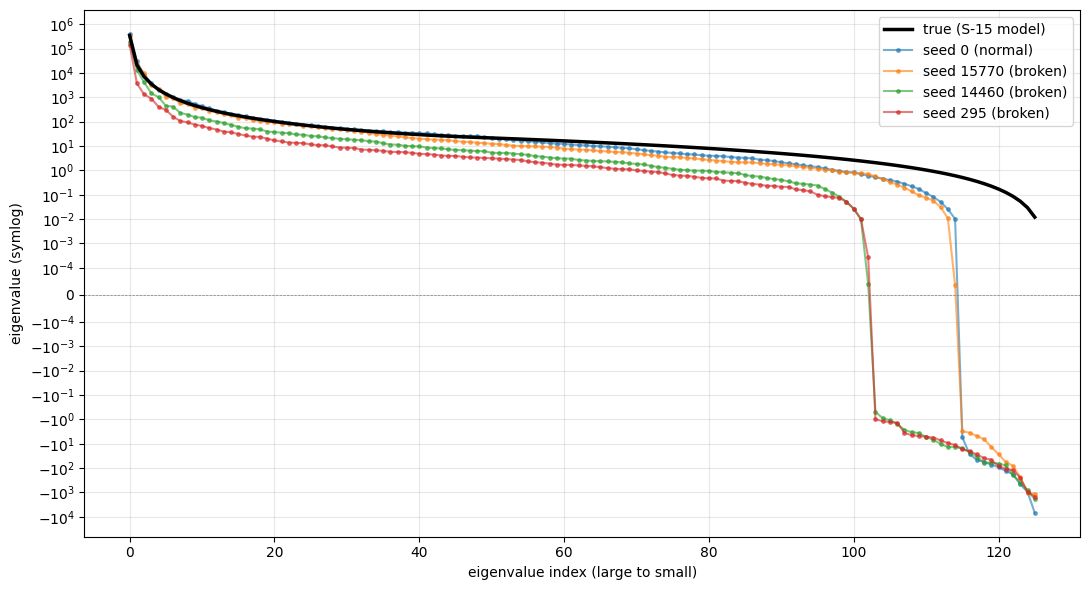

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(np.sort(ev_true)[::-1], 'k-', lw=2.5, label='true (S-15 model)', zorder=5)




for seed in [0, 15770, 14460, 295]:

    a = build_analyzer(seed, atoms=32)

    raw = build_raw_cov(a)

    ev = np.sort(np.linalg.eigvalsh(raw))[::-1]

    tag = 'normal' if seed == 0 else 'broken'

    ax.plot(ev, 'o-', ms=2.5, alpha=0.6, label=f'seed {seed} ({tag})')




ax.set_yscale('symlog', linthresh=1e-4)

ax.axhline(0, color='gray', lw=0.5, ls='--')

ax.set_xlabel('eigenvalue index (large to small)')

ax.set_ylabel('eigenvalue (symlog)')

ax.grid(alpha=0.3)

ax.legend()

plt.tight_layout()

plt.show()


In [17]:
from scipy.stats import spearmanr

a0 = build_analyzer(0, atoms=16)

sigma2_true = model_variance_S15(a0)

cov_true = cov_from_variance_S30(a0, sigma2_true)

ev_true = np.sort(np.linalg.eigvalsh(cov_true))[::-1]


def metrics(raw, ntop=100):

    ev = np.sort(np.linalg.eigvalsh(raw))[::-1]
    
    n_use = min(ntop, len(ev))

    bulk_dev = np.mean(np.log10(ev_true[:n_use]) - np.log10(np.maximum(ev[:n_use], 1e-10)))

    n_pos = np.sum(ev > 0)

    return bulk_dev, n_pos, np.mean(ev < 0)






records = []

for s in tqdm(range(300)):
    a = build_analyzer(s, atoms=16)
    raw = build_raw_cov(a)
    bd, npos, fneg = metrics(raw)
    D = np.median(a.D.values)
    records.append({"seed": s, "bulk_dev": bd, "n_pos": npos, "frac_neg": fneg, "D": D})






D = np.array([r["D"] for r in records])
bd = np.array([r["bulk_dev"] for r in records])
npos = np.array([r["n_pos"] for r in records])
fneg = np.array([r["frac_neg"] for r in records])
Dn = np.median(D[D > 0])
anom = (D < 0.5*Dn) | (D <= 0)



print(f"\nat 16 atoms: {np.sum(anom)}/300 anomalous ({100*np.mean(anom):.1f}%)")

print(f"normal D scale ~{Dn:.0f}\n")

for name, vals in [("bulk_dev", bd), ("n_pos", npos), ("frac_neg", fneg)]:
    rho, p = spearmanr(vals, D)

    
    print(f"{name:10s}: normal [{vals[~anom].min():.3f}, {vals[~anom].max():.3f}], "
          f"anom [{vals[anom].min():.3f}, {vals[anom].max():.3f}], "
          f"rho={rho:+.3f}")

100%|██████████| 300/300 [01:51<00:00,  2.69it/s]


at 16 atoms: 1/300 anomalous (0.3%)
normal D scale ~9931

bulk_dev  : normal [-0.508, 6.628], anom [0.085, 0.085], rho=-0.251
n_pos     : normal [49.000, 126.000], anom [125.000, 125.000], rho=+0.188
frac_neg  : normal [0.000, 0.611], anom [0.008, 0.008], rho=-0.188


In [23]:
rows = list(np.load(base / "data" / "anomaly_realfit_all14.npy", allow_pickle=True))
for r in rows:
    print(r["atoms"], r["seed"], r["method"], "->", r.get("error", "ok"), "| d =", r["d"])

disk_bad = np.load(base / "data" / "all_bad_seeds.npy")
print("\nall_bad_seeds.npy on disk:", disk_bad.shape)
print(disk_bad)

records = list(np.load(base / "data" / "failure_population.npy", allow_pickle=True))
print("\nfailure_population records:", len(records))

D = np.array([r["D"] for r in records])
atoms_arr = np.array([r["atoms"] for r in records])
finite = np.isfinite(D)
anom = np.zeros(len(records), dtype=bool)
for ac in np.unique(atoms_arr):
    m = (atoms_arr == ac) & finite
    Dn = np.median(D[m & (D > 1000)])
    anom |= m & ((D < 0.5 * Dn) | (D <= 0))
anom |= ~finite
print("recomputed anomalies:", int(anom.sum()))
for ac in np.unique(atoms_arr):
    m = atoms_arr == ac
    print(f"  {ac:3d} atoms: {int((anom & m).sum()):3d} / {int(m.sum())}")
bad14 = [(int(records[i]["atoms"]), int(records[i]["seed"])) for i in np.where(anom)[0]]
print("\nrecomputed bad list:", bad14)

16 3 raw -> NameError: name 'realfit_with_treatment' is not defined | d = nan
16 3 adaptive -> NameError: name 'realfit_with_treatment' is not defined | d = nan
16 3 mineig1e3 -> NameError: name 'realfit_with_treatment' is not defined | d = nan

all_bad_seeds.npy on disk: (1, 2)
[[16  3]]

failure_population records: 2000
recomputed anomalies: 1
   16 atoms:   1 / 2000

recomputed bad list: [(16, 3)]


Check system cores and then run the below analysis.  

In [18]:
import joblib

from joblib import Parallel, delayed

print("cores available:", os.cpu_count())

cores available: 12


In [19]:
# atom_counts = [16, 24, 32, 48]

# n_seeds = 16000

# ckpt_pop = base / "data" / "failure_population.npy"

# n_jobs = -1   



# true_ev = {}

# for ac in atom_counts:
#     a0 = build_analyzer(0, atoms=ac)
#     s2 = model_variance_S15(a0)
#     true_ev[ac] = np.sort(np.linalg.eigvalsh(cov_from_variance_S30(a0, s2)))[::-1]



# def fit_one(ac, s):

#     try:
#         a = build_analyzer(s, atoms=ac)
#         raw = build_raw_cov(a)
#         ev = np.sort(np.linalg.eigvalsh(raw))[::-1]
#         n = min(80, len(ev))
#         pos = ev[ev > 0]


#         return {"atoms": ac, "seed": s,
#                 "D": float(np.median(a.D.values)),
#                 "cond": float(np.linalg.cond(a.diff.covariance_matrix.values)),
#                 "frac_neg": float(np.mean(ev < 0)),
#                 "n_pos": int(np.sum(ev > 0)),
#                 "lmin": float(ev[-1]), "lmax": float(ev[0]),
#                 "kappa_pos": float(ev[0] / pos[-1]) if pos.size else np.inf,
#                 "bulk_dev": float(np.mean(np.log10(true_ev[ac][:n])
#                                           - np.log10(np.maximum(ev[:n], 1e-10))))}
    

#     except Exception as e:

#         return {"atoms": ac, "seed": s, "D": np.nan, "error": f"{type(e).__name__}"}




# test = fit_one(32, 0)
# assert np.isfinite(test["D"]), f"pre-flight FAILED: {test.get('error')}"
# print(f"  OK: 32-atom seed 0 D={test['D']:.1f}\n")


# if os.path.exists(ckpt_pop):
#     records = list(np.load(ckpt_pop, allow_pickle=True))
#     done = {(r["atoms"], r["seed"]) for r in records}
#     print(f"resuming - {len(done)} already done")
# else:
#     records, done = [], set()


# jobs = [(ac, s) for ac in atom_counts for s in range(n_seeds) if (ac, s) not in done]
# print(f"running {len(jobs)} fits across {n_jobs if n_jobs>0 else os.cpu_count()} cores...\n")


# chunk = 2000
# for i in range(0, len(jobs), chunk):
#     batch = jobs[i:i+chunk]
#     out = Parallel(n_jobs=n_jobs, verbose=5)(delayed(fit_one)(ac, s) for ac, s in batch)
#     records.extend(out)
#     np.save(ckpt_pop, np.array(records, dtype=object))
#     print(f"  checkpoint: {len(records)} done")


# np.save(ckpt_pop, np.array(records, dtype=object))
# print(f"\ndone: {len(records)} total fits")

In [20]:
# records = list(np.load(ckpt_pop, allow_pickle=True))

# D = np.array([r["D"] for r in records])

# atoms_arr = np.array([r["atoms"] for r in records])

# finite = np.isfinite(D)


# anom = np.zeros(len(records), dtype=bool)

# for ac in np.unique(atoms_arr):
#     m = (atoms_arr == ac) & finite
#     Dn = np.median(D[m & (D > 1000)])
#     anom |= m & ((D < 0.5*Dn) | (D <= 0))
# anom |= ~finite


# print(f"total fits: {len(records)}")
# print(f"total anomalies: {np.sum(anom)}\n")


# for ac in np.unique(atoms_arr):
#     m = atoms_arr == ac
#     print(f"  {ac:3d} atoms: {np.sum(anom & m):3d} anomalies / {np.sum(m)} "
#           f"({100*np.mean(anom[m]):.3f}%)")



# bad = [(records[i]["atoms"], records[i]["seed"]) for i in np.where(anom)[0]]

# np.save(base / "data" / "all_bad_seeds.npy", np.array(bad))

In [21]:
# from scipy.stats import spearmanr

# records = list(np.load(ckpt_pop, allow_pickle=True))

# D = np.array([r["D"] for r in records])

# atoms_arr = np.array([r["atoms"] for r in records])

# finite = np.isfinite(D)




# anom = np.zeros(len(records), dtype=bool)

# for ac in np.unique(atoms_arr):
#     m = (atoms_arr == ac) & finite
#     Dn = np.median(D[m & (D > 1000)])
#     anom |= m & ((D < 0.5*Dn) | (D <= 0))




# metric_names = ["cond", "frac_neg", "n_pos", "kappa_pos", "bulk_dev", "lmin"]

# print(f"testing {np.sum(anom)} anomalies vs {np.sum(finite & ~anom)} normal\n")

# print(f"{'metric':>10s} {'anom med':>11s} {'normal med':>11s} {'rho':>7s} {'separation':>11s}")



# for name in metric_names:
#     vals = np.array([r.get(name, np.nan) for r in records], dtype=float)

#     ok = finite & np.isfinite(vals)

#     v, a = vals[ok], anom[ok]


#     if a.sum() == 0:
#         continue
#     rho, _ = spearmanr(v, D[ok])

#     sep = np.mean([np.mean(v[~a] < av) for av in v[a]])

#     print(f"{name:>10s} {np.median(v[a]):11.3f} {np.median(v[~a]):11.3f} {rho:+7.3f} {sep:11.2f}")


In [22]:
# records = list(np.load(ckpt_pop, allow_pickle=True))

# D = np.array([r["D"] for r in records])

# atoms_arr = np.array([r["atoms"] for r in records])

# kpos = np.array([r.get("kappa_pos", np.nan) for r in records], dtype=float)

# finite = np.isfinite(D) & np.isfinite(kpos)





# anom = np.zeros(len(records), dtype=bool)
# for ac in np.unique(atoms_arr):
#     m = (atoms_arr == ac) & finite
#     Dn = np.median(D[m & (D > 1000)])
#     anom |= m & ((D < 0.5*Dn) | (D <= 0))


# print("check - the gap:")
# print(f"  highest normal kappa_pos:    {np.max(kpos[finite & ~anom]):.3e}")
# print(f"  lowest anomalous kappa_pos:  {np.min(kpos[finite & anom]):.3e}")
# gap = np.min(kpos[finite & anom]) > np.max(kpos[finite & ~anom])
# print(f"  clean gap (no overlap): {gap}")
# if not gap:
#     n_above = np.sum(kpos[finite & ~anom] > np.min(kpos[finite & anom]))
#     print(f"  normals above the lowest anomaly: {n_above}")




# print("check - separation within each atom count:")
# for ac in np.unique(atoms_arr):
#     m = (atoms_arr == ac) & finite
#     a = anom[m]
#     if a.sum() == 0: continue
#     k = kpos[m]
#     clean = k[a].min() > k[~a].max()
#     print(f"  {ac} atoms: lowest anom {k[a].min():.2e} vs highest normal {k[~a].max():.2e}  clean={clean}")





# print("\ncheck - out of sample prediction (hold out each atom count):")
# for held in np.unique(atoms_arr):
#     train = (atoms_arr != held) & finite
#     test = (atoms_arr == held) & finite
#     tn = kpos[train & ~anom]; ta = kpos[train & anom]
#     if ta.size == 0: continue
#     thresh = 10**((np.log10(ta.min()) + np.log10(tn.max()))/2)
#     pred = kpos[test] > thresh
#     true = anom[test]
#     tp = np.sum(pred & true); fp = np.sum(pred & ~true); fn = np.sum(~pred & true)
#     print(f"  hold {held}: thresh={thresh:.2e}, caught {tp}/{tp+fn} failures, {fp} false alarms")



# fig, ax = plt.subplots(figsize=(11,5))
# for ac in np.unique(atoms_arr):
#     m = (atoms_arr == ac) & finite
#     ax.scatter(np.full(np.sum(m & ~anom), ac), kpos[m & ~anom], s=3, alpha=0.2, color='gray')
#     ax.scatter(np.full(np.sum(m & anom), ac), kpos[m & anom], s=80, color='crimson', marker='x', zorder=5)
# ax.set_yscale('log')
# ax.set_xlabel('atoms'); ax.set_ylabel('kappa_pos (positive subspace condition number)')
# ax.grid(alpha=0.3)
# plt.tight_layout()
# plt.savefig(base / "plots" / "kappa_pos_separation.png", dpi=150)
# plt.show()